# Lab 18: Model Evaluation — Metrics that Matter

**Objectives:** By the end of this lab, you will be able to:
1. Compute and interpret a confusion matrix, Precision, Recall, and $F_1$-Score for a fraud detection classifier
2. Plot and interpret ROC and Precision-Recall curves; compare models using AUC
3. Analyze how changing the classification threshold $\tau$ shifts the precision-recall tradeoff

**Estimated time:** 30 minutes  
**Data source:** [Kaggle Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) — 284,807 transactions, 492 frauds (0.172%)  
**Key packages:** pandas, numpy, scikit-learn, matplotlib, seaborn  

**Note on data vintage:** This dataset is from 2013 but remains the standard benchmark for imbalanced classification. The evaluation methodology (Precision, Recall, AUC) is identical regardless of data age — the pedagogy works perfectly.

In [1]:
# -----------------------------------------------------------
# SETUP — Run this cell first. Install any missing packages.
# -----------------------------------------------------------

# Uncomment if running for the first time:
# !pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve, auc,
    f1_score, precision_score, recall_score
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("Setup complete ✓")

Setup complete ✓


---
## Part 1: The Accuracy Paradox — Guided Walkthrough

### What we're doing and why

In lecture, we learned that accuracy is misleading for imbalanced data. Now we'll see it firsthand.

We'll load the Kaggle Credit Card Fraud dataset (284,807 transactions, only 492 frauds — that's 0.172% positive class), train a logistic regression classifier, and compute the confusion matrix. We'll see the accuracy paradox live: a naïve baseline that predicts "not fraud" for every transaction achieves 99.83% accuracy while catching zero fraud.

### The data

Each row is a credit card transaction. Features V1–V28 are PCA-transformed (anonymized for privacy). `Time` is seconds since the first transaction. `Amount` is the transaction amount in euros. `Class` is our target: 0 = legitimate, 1 = fraud.

In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

100%|███████████████████████████████████████| 66.0M/66.0M [02:08<00:00, 537kB/s]

Extracting files...


Path to dataset files: /Users/rebeccamilde/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3


In [11]:
# Step 1: Load data
# Download from Kaggle
# Place creditcard.csv in the same directory as this notebook, or update the path below.

# Option A: Load from local file
df = pd.read_csv('creditcard.csv')

# Option B (Google Colab): Upload from Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/data/creditcard.csv')


print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud rate: {df['Class'].mean():.4%}")

Dataset shape: (284807, 31)

Class distribution:
0    284315
1       492
Name: Class, dtype: int64

Fraud rate: 0.1727%


In [3]:
# Step 2: Inspect the data — always look before modeling
print("First 5 rows:")
print(df.head())
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nTransaction amount stats:")
print(df['Amount'].describe())

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       

In [4]:
# Step 3: Prepare features and target
# Drop 'Time' (not useful for this exercise) and separate X, y
X = df.drop(columns=['Class', 'Time'])
y = df['Class']

# Scale the 'Amount' feature (V1-V28 are already PCA-scaled)
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

# Train/test split — stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} transactions ({y_train.sum()} frauds)")
print(f"Test set:     {X_test.shape[0]:,} transactions ({y_test.sum()} frauds)")

Training set: 227,845 transactions (394 frauds)
Test set:     56,962 transactions (98 frauds)


In [5]:
# Step 4: The naïve baseline — predict "not fraud" for everything
# This demonstrates the accuracy paradox from lecture

naive_predictions = np.zeros(len(y_test))  # All zeros = "not fraud"
naive_accuracy = (naive_predictions == y_test).mean()

print(f"Naïve baseline accuracy: {naive_accuracy:.4%}")
print(f"Naïve baseline recall (fraud class): {recall_score(y_test, naive_predictions):.4%}")
print(f"\n→ 99.83% accuracy, 0% recall. The accuracy paradox in action.")

Naïve baseline accuracy: 99.8280%
Naïve baseline recall (fraud class): 0.0000%

→ 99.83% accuracy, 0% recall. The accuracy paradox in action.


In [6]:
# Step 5: Train a logistic regression classifier
# This is the model from Topic 17 — now we evaluate it properly

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Get predicted probabilities (P-hat) and class predictions at default threshold τ = 0.5
y_prob = log_reg.predict_proba(X_test)[:, 1]  # P(fraud)
y_pred = log_reg.predict(X_test)  # Binary prediction at τ = 0.5

print(f"Model accuracy: {(y_pred == y_test).mean():.4%}")
print(f"\nBut let's look at the confusion matrix...")

Model accuracy: 99.9157%

But let's look at the confusion matrix...


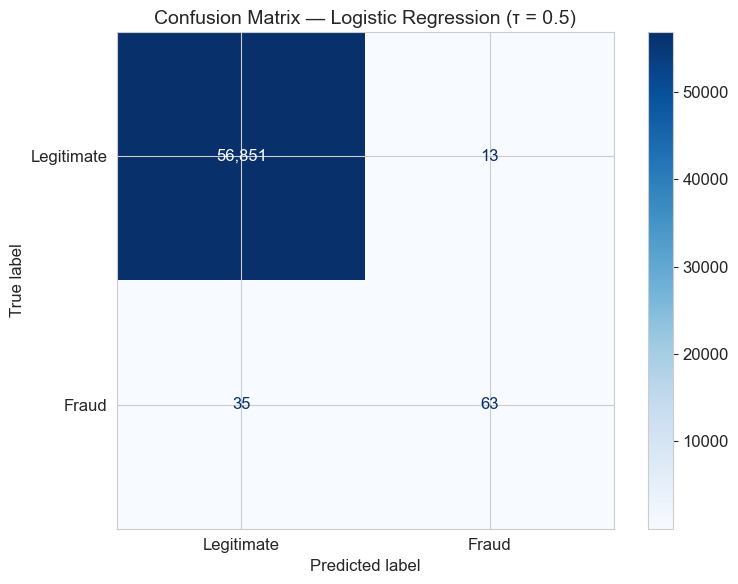

True Positives (fraud caught):     63
False Negatives (fraud missed):     35
False Positives (legit blocked):    13
True Negatives (legit approved):    56,851


In [12]:
# Step 6: Confusion matrix — the real picture

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=ax, cmap='Blues', values_format=',')
ax.set_title('Confusion Matrix — Logistic Regression (τ = 0.5)', fontsize=14)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives (fraud caught):     {tp}")
print(f"False Negatives (fraud missed):     {fn}")
print(f"False Positives (legit blocked):    {fp}")
print(f"True Negatives (legit approved):    {tn:,}")

In [13]:
# Step 7: Classification report — Precision, Recall, F1 per class

print("Classification Report (τ = 0.5):")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))
print("\n→ Focus on the FRAUD row. That's the class that matters.")
print("→ 'macro avg' = unweighted mean across classes.")
print("→ 'weighted avg' = weighted by class size (dominated by majority class — just like accuracy).")

Classification Report (τ = 0.5):
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962


→ Focus on the FRAUD row. That's the class that matters.
→ 'macro avg' = unweighted mean across classes.
→ 'weighted avg' = weighted by class size (dominated by majority class — just like accuracy).


### What we found

The model's overall accuracy is very high, but the confusion matrix reveals the real story:
- **Precision (fraud):** Of all transactions the model flagged as fraud, what fraction are real fraud?
- **Recall (fraud):** Of all actual frauds, what fraction did the model catch?

The default threshold $\tau = 0.5$ may not be optimal for fraud detection. In Part 2, we'll explore how changing $\tau$ shifts the tradeoff.

---
## Part 2: ROC Curve, PR Curve, and Threshold Analysis

### What we're doing and why

The confusion matrix at $\tau = 0.5$ is just one operating point. The ROC curve shows us ALL possible operating points simultaneously. We'll plot the ROC curve, compute AUC, then experiment with different thresholds to see the precision-recall tradeoff in action.

Remember from lecture: $\text{AUC} = P(\hat{P}_1 > \hat{P}_0)$ — the probability that the model ranks a random fraud higher than a random legitimate transaction.

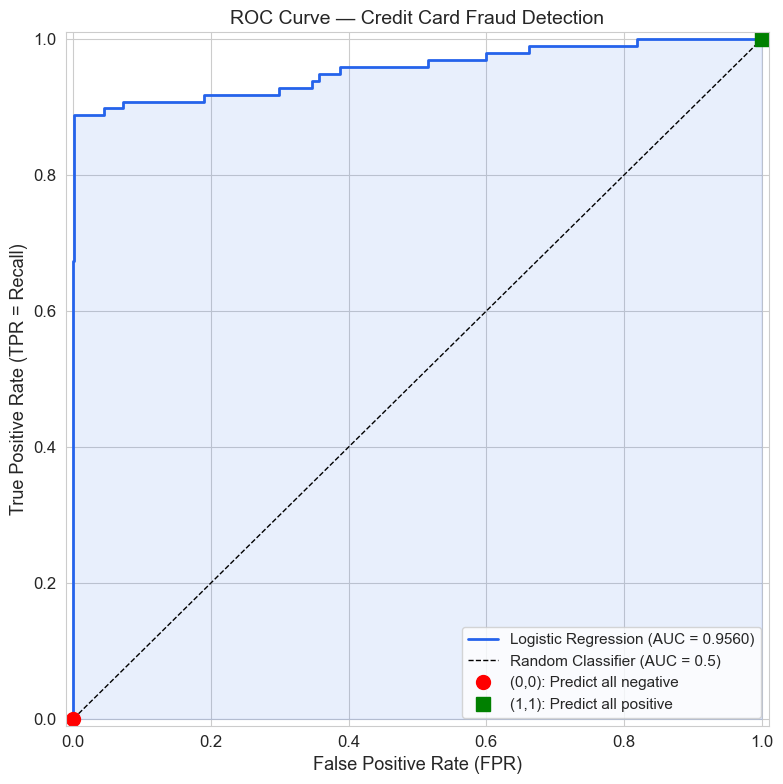

AUC = 0.9560

Interpretation: There is a 95.6% probability that the model
ranks a random fraud transaction higher than a random legitimate transaction.


In [14]:
# Step 1: Plot the ROC curve

fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(fpr, tpr, color='#2563eb', linewidth=2, label=f'Logistic Regression (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#2563eb')

# Mark key reference points
ax.plot(0, 0, 'ro', markersize=10, label='(0,0): Predict all negative')
ax.plot(1, 1, 'gs', markersize=10, label='(1,1): Predict all positive')

ax.set_xlabel('False Positive Rate (FPR)', fontsize=13)
ax.set_ylabel('True Positive Rate (TPR = Recall)', fontsize=13)
ax.set_title('ROC Curve — Credit Card Fraud Detection', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()

print(f"AUC = {auc_score:.4f}")
print(f"\nInterpretation: There is a {auc_score:.1%} probability that the model")
print(f"ranks a random fraud transaction higher than a random legitimate transaction.")

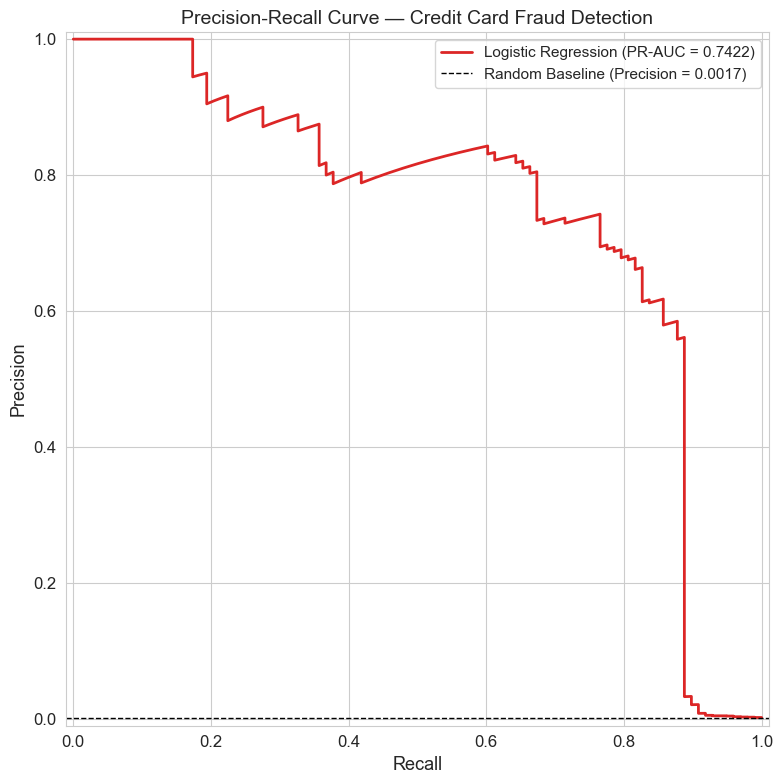

PR-AUC = 0.7422

Notice: The PR curve is much harder to look 'good' on than the ROC curve.
That's because it ignores TN — it focuses entirely on fraud-class performance.


In [15]:
# Step 2: Plot the Precision-Recall curve
# For highly imbalanced data, the PR curve is often more informative than ROC

precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall_vals, precision_vals)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(recall_vals, precision_vals, color='#dc2626', linewidth=2,
        label=f'Logistic Regression (PR-AUC = {pr_auc:.4f})')

# Baseline: random classifier precision = positive class prevalence
baseline = y_test.mean()
ax.axhline(y=baseline, color='k', linestyle='--', linewidth=1,
           label=f'Random Baseline (Precision = {baseline:.4f})')

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curve — Credit Card Fraud Detection', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()

print(f"PR-AUC = {pr_auc:.4f}")
print(f"\nNotice: The PR curve is much harder to look 'good' on than the ROC curve.")
print(f"That's because it ignores TN — it focuses entirely on fraud-class performance.")

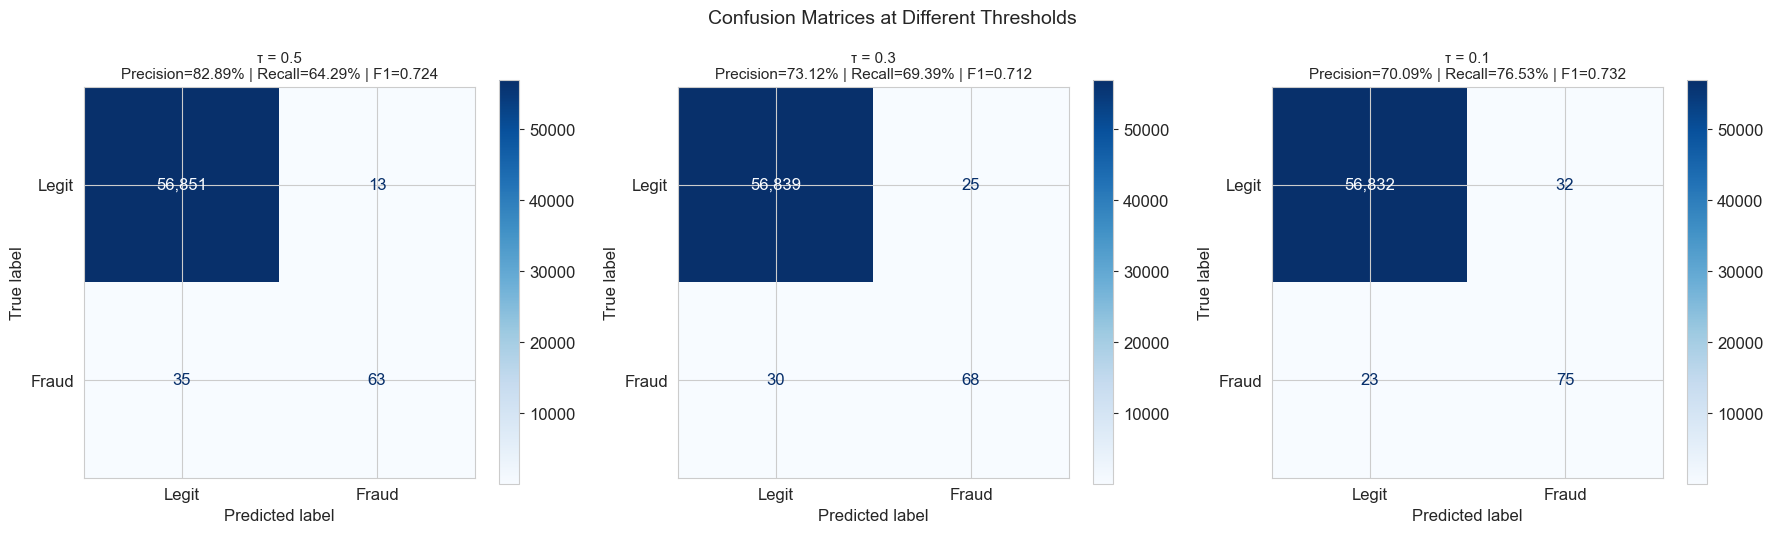


As τ decreases: Recall ↑ (catch more fraud), Precision ↓ (more false alarms)
This is the precision-recall tradeoff from lecture.


In [16]:
# Step 3: Compare confusion matrices at 3 different thresholds
# This is where you see the precision-recall tradeoff in action

thresholds_to_test = [0.5, 0.3, 0.1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, tau in enumerate(thresholds_to_test):
    y_pred_tau = (y_prob >= tau).astype(int)
    cm_tau = confusion_matrix(y_test, y_pred_tau)
    
    prec = precision_score(y_test, y_pred_tau, zero_division=0)
    rec = recall_score(y_test, y_pred_tau)
    f1 = f1_score(y_test, y_pred_tau)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_tau, display_labels=['Legit', 'Fraud'])
    disp.plot(ax=axes[i], cmap='Blues', values_format=',')
    axes[i].set_title(f'τ = {tau}\nPrecision={prec:.2%} | Recall={rec:.2%} | F1={f1:.3f}',
                      fontsize=11)

plt.suptitle('Confusion Matrices at Different Thresholds', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nAs τ decreases: Recall ↑ (catch more fraud), Precision ↓ (more false alarms)")
print("This is the precision-recall tradeoff from lecture.")

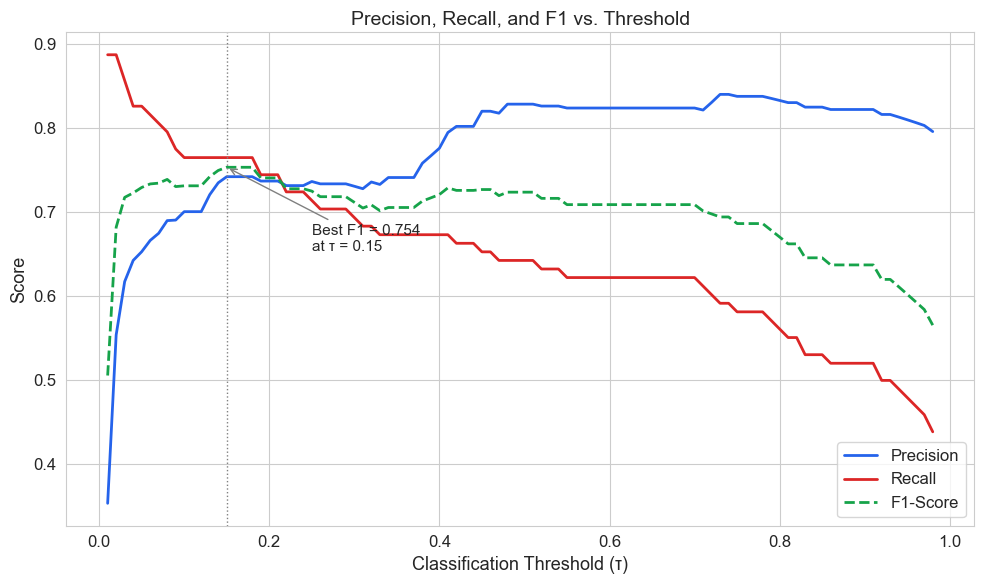


Optimal threshold for F1: τ = 0.15 (F1 = 0.754)

But remember from lecture: F1 assumes equal cost of FP and FN.
In fraud detection, you might prefer a lower τ to maximize Recall (catch more fraud).


In [17]:
# Step 4: Find the threshold that maximizes F1 for the fraud class

# Compute F1 at many thresholds
f1_scores = []
precision_scores = []
recall_scores = []
threshold_range = np.arange(0.01, 0.99, 0.01)

for tau in threshold_range:
    y_pred_tau = (y_prob >= tau).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_tau, zero_division=0))
    precision_scores.append(precision_score(y_test, y_pred_tau, zero_division=0))
    recall_scores.append(recall_score(y_test, y_pred_tau, zero_division=0))

# Plot metrics vs threshold
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_range, precision_scores, label='Precision', color='#2563eb', linewidth=2)
ax.plot(threshold_range, recall_scores, label='Recall', color='#dc2626', linewidth=2)
ax.plot(threshold_range, f1_scores, label='F1-Score', color='#16a34a', linewidth=2, linestyle='--')

best_tau = threshold_range[np.argmax(f1_scores)]
best_f1 = max(f1_scores)
ax.axvline(x=best_tau, color='gray', linestyle=':', linewidth=1)
ax.annotate(f'Best F1 = {best_f1:.3f}\nat τ = {best_tau:.2f}',
            xy=(best_tau, best_f1), xytext=(best_tau + 0.1, best_f1 - 0.1),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_xlabel('Classification Threshold (τ)', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Precision, Recall, and F1 vs. Threshold', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nOptimal threshold for F1: τ = {best_tau:.2f} (F1 = {best_f1:.3f})")
print(f"\nBut remember from lecture: F1 assumes equal cost of FP and FN.")
print(f"In fraud detection, you might prefer a lower τ to maximize Recall (catch more fraud).")

### What we found

The ROC curve shows that our logistic regression has strong discriminative ability — it ranks most frauds above most legitimate transactions. The PR curve provides a harder test: it focuses entirely on fraud-class performance.

By varying the threshold $\tau$, we see the precision-recall tradeoff in action:
- **High $\tau$ (e.g., 0.5):** Conservative — high precision, low recall. Few false alarms, but misses many frauds.
- **Low $\tau$ (e.g., 0.1):** Aggressive — high recall, lower precision. Catches more fraud, but blocks more legitimate transactions.

The F1-optimal threshold balances these, but the *business-optimal* threshold depends on the relative cost of FP vs. FN.

---
## Part 3: Try It Yourself

### Capacity-Constrained Fraud Investigation

Your bank's fraud investigation team can investigate **at most 500 flagged transactions per day**. The test set represents one day of transactions.

**Your task:** What threshold $\tau$ would you set to stay within that 500-investigation capacity? What Recall does this operating point achieve?

In [23]:
max_investigations = 500

# TODO: Write a loop over thresholds from 0.01 to 0.99 (step 0.01).
# For each threshold tau:
#   1. Count how many transactions are flagged: (y_prob >= tau).sum()
#   2. If n_flagged <= max_investigations:
#        - Compute binary predictions at that threshold
#        - Compute Recall and Precision
#        - Print the results
#        - Break out of the loop
#
# Hint: Follow the same pattern from Step 3 (cell above) where we
# tested thresholds [0.5, 0.3, 0.1] — but now automate the search.

# YOUR CODE HERE

for tau in np.arange(0.01, 0.99, 0.01):
    n_flagged = (y_prob >= tau).sum()
    if n_flagged <= max_investigations:
        y_pred_capacity = (y_prob >= tau.astype(int))
        rec = recall_score(y_test, y_pred_capacity)
        prec = precision_score(y_test, y_pred_capacity, zero_division = 0)
        print(f"tau = {tau:.2f} -> {n_flagged} flagged Recall = {rec:.2%} Precision = {prec:.2%}")
        break


# TODO: Interpret — is this Recall acceptable for a fraud team?
# What would you recommend to the VP of Risk?

tau = 0.01 -> 246 flagged Recall = 100.00% Precision = 0.17%


---
## Summary

In this lab, you:
1. **Witnessed the accuracy paradox** — a naïve model achieves 99.83% accuracy while catching zero fraud
2. **Computed the confusion matrix** and extracted Precision, Recall, and $F_1$ for the fraud class
3. **Plotted ROC and PR curves** — two complementary views of model discrimination
4. **Varied the threshold $\tau$** and observed the precision-recall tradeoff in action
5. **Made a capacity-constrained decision** — choosing an operating point based on real-world constraints

**Key takeaway:** The "best" threshold depends on the business context, not just the math. Model evaluation is where data science meets economics.